In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
notebook_path = Path.cwd()
base_path = notebook_path.parent

raw_path = base_path / "data" / "raw" 
plot_path = base_path / "fig"

In [3]:
abund_mass=pd.read_csv(raw_path / "abundance_biomass.csv", sep = ";")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\LENOVO\\Documents\\Abundance_Biomass\\abundance_biomass\\code\\data\\raw\\abundance_biomass.csv'

In [4]:
total_ab_site_replicate_series = abund_mass.groupby(['site', 'replicate', 'month', 'sample']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight', 'sum')
).reset_index()

In [5]:
# Total Abundance & Biomass per Site and Replicate
mean_ab_series = total_ab_site_replicate_series.groupby(['month', 'sample']).agg(
    abundance_mean=('abundance', 'mean'),
    abundance_std=('abundance', 'std'),
    biomass_mean=('biomass', 'mean'),
    biomass_std=('biomass', 'std')
).reset_index()

# Total Abundance & Biomass per Site and Replicate
mean_ab_site_series = total_ab_site_replicate_series.groupby(['site', 'month', 'sample']).agg(
    abundance_mean=('abundance', 'mean'),
    abundance_std=('abundance', 'std'),
    biomass_mean=('biomass', 'mean'),
    biomass_std=('biomass', 'std')
).reset_index()

total_ab_series = abund_mass.groupby(['month', 'sample']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight', 'sum')
).reset_index()

# Total Abundance & Biomass per Site and Replicate
total_ab_site_series = abund_mass.groupby(['site', 'month', 'sample']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight', 'sum')
).reset_index()

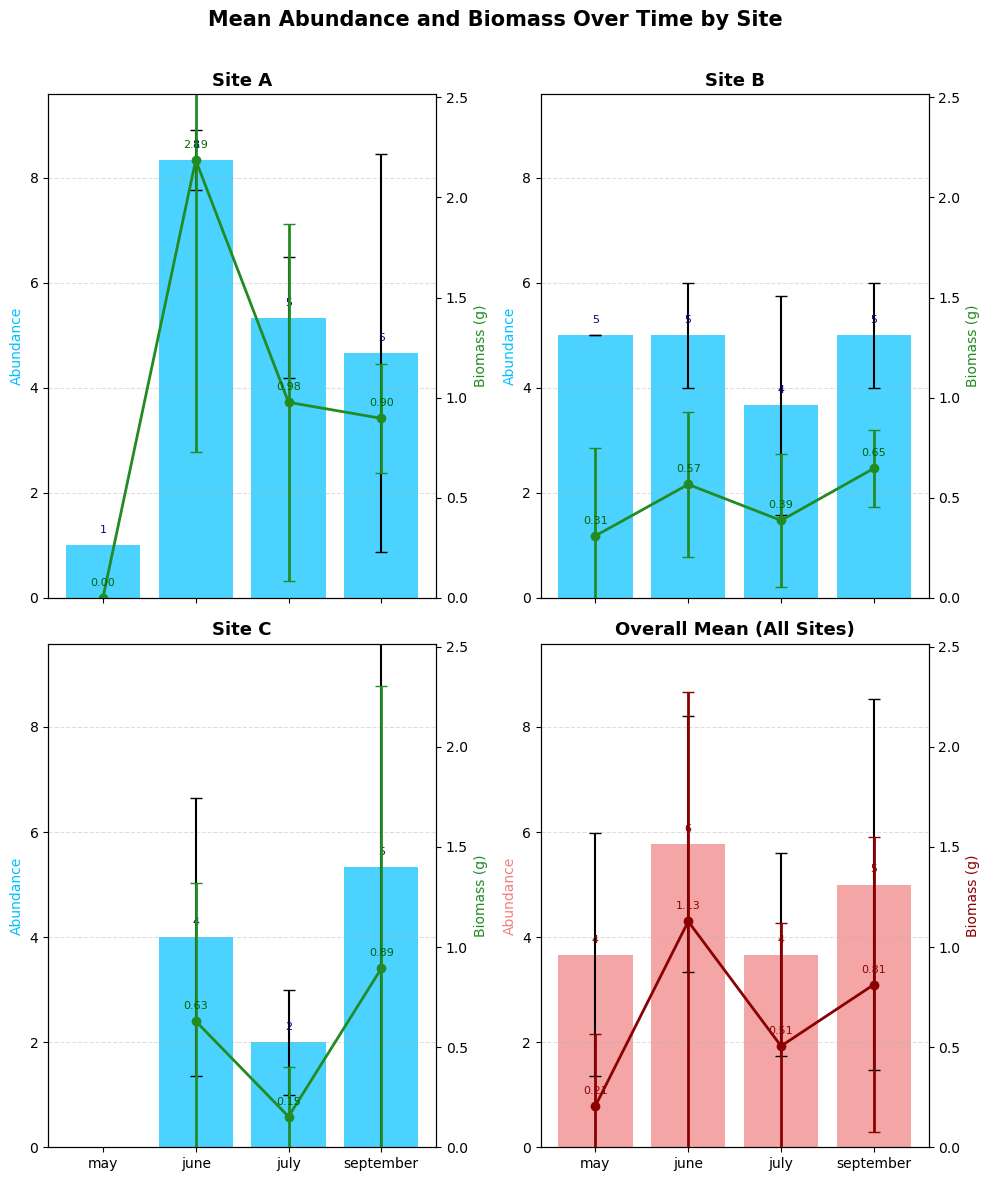

In [6]:
# --- Ensure month order ---
month_order = ['may', 'june', 'july', 'september']

mean_ab_series['month'] = pd.Categorical(mean_ab_series['month'], categories=month_order, ordered=True)
mean_ab_site_series['month'] = pd.Categorical(mean_ab_site_series['month'], categories=month_order, ordered=True)

mean_ab_series = mean_ab_series.sort_values(['month'])
mean_ab_site_series = mean_ab_site_series.sort_values(['site', 'month'])

# --- Compute global axis limits for consistency ---
y1_min = 0
y1_max = max(mean_ab_site_series['abundance_mean'].max(),
             mean_ab_series['abundance_mean'].max()) * 1.15

y2_min = 0
y2_max = max(mean_ab_site_series['biomass_mean'].max(),
             mean_ab_series['biomass_mean'].max()) * 1.15

# --- Create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(10, 12), sharex=True)
axes = axes.flatten()

# --- Loop through sites (A–C) ---
for i, site in enumerate(sites):
    site_data = mean_ab_site_series[mean_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance (bar + error)
    bars = ax1.bar(site_data['month'], site_data['abundance_mean'],
                   yerr=site_data['abundance_std'], capsize=4,
                   color='deepskyblue', alpha=0.7, label='Abundance')
    
    # Plot biomass (line + error)
    ax2.errorbar(site_data['month'], site_data['biomass_mean'],
                 yerr=site_data['biomass_std'], color='forestgreen',
                 marker='o', linewidth=2, capsize=4, label='Biomass')
    
    # Add labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
                 f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='navy')
    
    # Add labels for biomass
    for x, y in zip(site_data['month'], site_data['biomass_mean']):
        ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='darkgreen')
    
    # Axis formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=13, weight='bold')
    ax1.set_ylabel('Abundance', color='deepskyblue', fontsize=10)
    ax2.set_ylabel('Biomass (g)', color='forestgreen', fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Fourth subplot: Overall Mean (All Sites) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(mean_ab_series['month'], mean_ab_series['abundance_mean'],
               yerr=mean_ab_series['abundance_std'], capsize=4,
               color='lightcoral', alpha=0.7, label='Abundance')

ax2.errorbar(mean_ab_series['month'], mean_ab_series['biomass_mean'],
             yerr=mean_ab_series['biomass_std'], color='darkred',
             marker='o', linewidth=2, capsize=4, label='Biomass')

# Add labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
             f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='maroon')

for x, y in zip(mean_ab_series['month'], mean_ab_series['biomass_mean']):
    ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='darkred')

# Axis formatting
ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title("Overall Mean (All Sites)", fontsize=13, weight='bold')
ax1.set_ylabel('Abundance', color='lightcoral', fontsize=10)
ax2.set_ylabel('Biomass (g)', color='darkred', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Global formatting ---
fig.suptitle("Mean Abundance and Biomass Over Time by Site", fontsize=15, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "mean_abundance_biomass_sites.png", dpi=300)
plt.show()

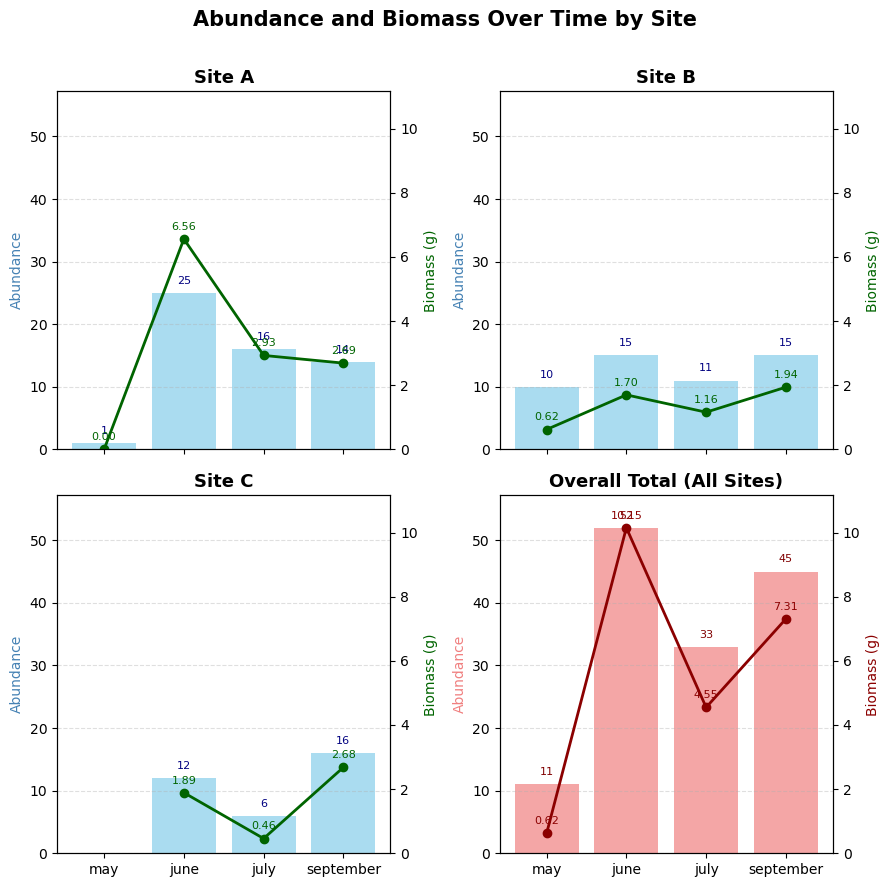

In [7]:
# --- Ensure months are in correct order ---
month_order = ['may', 'june', 'july', 'september']
total_ab_site_series['month'] = pd.Categorical(
    total_ab_site_series['month'], categories=month_order, ordered=True
)
total_ab_site_series = total_ab_site_series.sort_values(['site', 'month'])

total_ab_series['month'] = pd.Categorical(
    total_ab_series['month'], categories=month_order, ordered=True
)
total_ab_series = total_ab_series.sort_values(['month'])

# --- Compute global axis limits for consistency ---
y1_min = 0
y1_max = max(total_ab_site_series['abundance'].max(),
             total_ab_series['abundance'].max()) * 1.1

y2_min = 0
y2_max = max(total_ab_site_series['biomass'].max(),
             total_ab_series['biomass'].max()) * 1.1

# --- Define site list and create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True)
axes = axes.flatten()

# --- Loop through sites (A, B, C) ---
for i, site in enumerate(sites):
    site_data = total_ab_site_series[total_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance as bars
    bars = ax1.bar(site_data['month'], site_data['abundance'], 
                   color='skyblue', alpha=0.7, label='Abundance')
    
    # Plot biomass as line
    ax2.plot(site_data['month'], site_data['biomass'], 
             color='darkgreen', marker='o', linewidth=2, label='Biomass')
    
    # Add bar magnitude labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
                 f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='navy')
    
    # Add biomass value labels
    for x, y in zip(site_data['month'], site_data['biomass']):
        ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='darkgreen')
    
    # Formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=13, weight='bold')
    ax1.set_ylabel('Abundance', color='steelblue', fontsize=10)
    ax2.set_ylabel('Biomass (g)', color='darkgreen', fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Fourth subplot (Overall Total) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(total_ab_series['month'], total_ab_series['abundance'],
               color='lightcoral', alpha=0.7, label='Abundance')
ax2.plot(total_ab_series['month'], total_ab_series['biomass'],
         color='darkred', marker='o', linewidth=2, label='Biomass')

# Add labels for abundance and biomass
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
             f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='maroon')

for x, y in zip(total_ab_series['month'], total_ab_series['biomass']):
    ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='darkred')

ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title('Overall Total (All Sites)', fontsize=13, weight='bold')
ax1.set_ylabel('Abundance', color='lightcoral', fontsize=10)
ax2.set_ylabel('Biomass (g)', color='darkred', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Global formatting ---
fig.suptitle('Abundance and Biomass Over Time by Site', fontsize=15, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "time_series_scaled_labels.png", dpi=300)
plt.show()

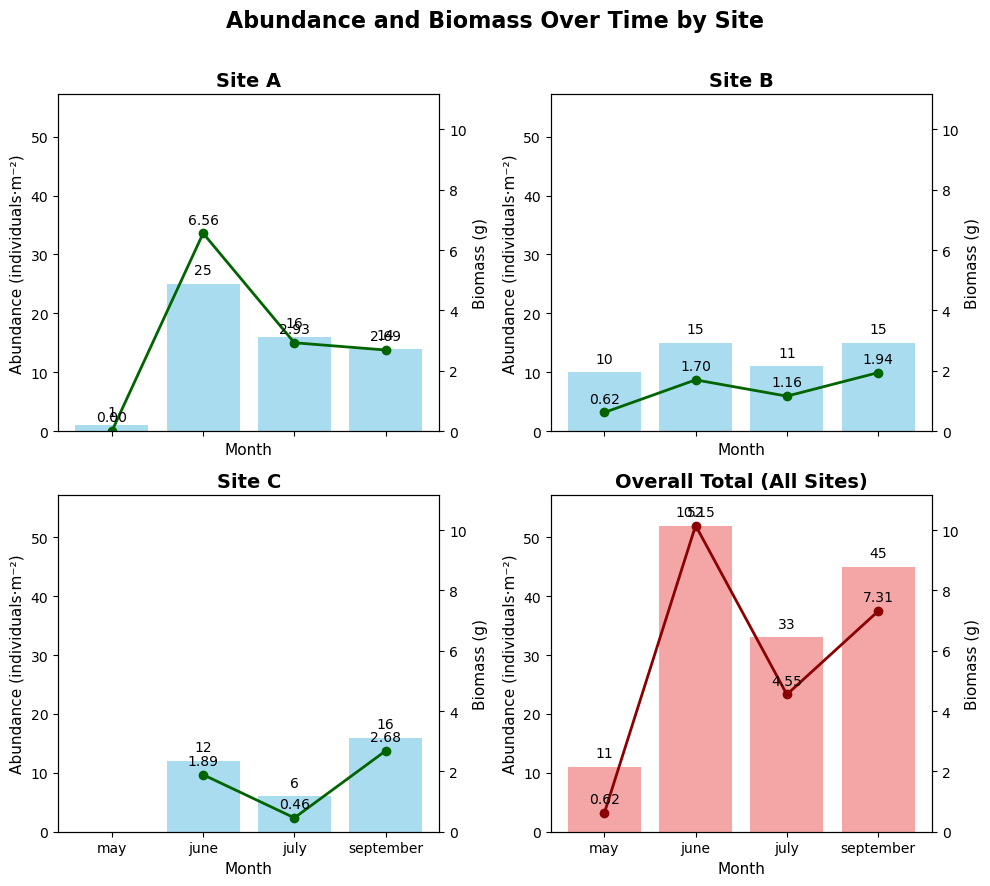

In [8]:
# --- Ensure months are in correct order ---
month_order = ['may', 'june', 'july', 'september']

total_ab_site_series['month'] = pd.Categorical(
    total_ab_site_series['month'], categories=month_order, ordered=True
)
total_ab_site_series = total_ab_site_series.sort_values(['site', 'month'])

total_ab_series['month'] = pd.Categorical(
    total_ab_series['month'], categories=month_order, ordered=True
)
total_ab_series = total_ab_series.sort_values(['month'])

# --- Compute global axis limits for consistency ---
y1_min = 0
y1_max = max(total_ab_site_series['abundance'].max(),
             total_ab_series['abundance'].max()) * 1.1

y2_min = 0
y2_max = max(total_ab_site_series['biomass'].max(),
             total_ab_series['biomass'].max()) * 1.1

# --- Define site list and create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True)
axes = axes.flatten()

# --- Loop through sites (A, B, C) ---
for i, site in enumerate(sites):
    site_data = total_ab_site_series[total_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance as bars
    bars = ax1.bar(site_data['month'], site_data['abundance'], 
                   color='skyblue', alpha=0.7, label='Abundance')
    
    # Plot biomass as line
    ax2.plot(site_data['month'], site_data['biomass'], 
             color='darkgreen', marker='o', linewidth=2, label='Biomass')
    
    # Add bar magnitude labels (abundance)
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
                 f"{height:.0f}", ha='center', va='bottom', fontsize=10, color='black')
    
    # Add biomass value labels
    for x, y in zip(site_data['month'], site_data['biomass']):
        ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='black')
    
    # Formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=14, weight='bold')
    ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=11, color='black')
    ax2.set_ylabel('Biomass (g)', fontsize=11, color='black')
    ax1.set_xlabel('Month', fontsize=11)
    
    # Remove grid lines
    ax1.grid(False)
    ax2.grid(False)

# --- Fourth subplot (Overall Total) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(total_ab_series['month'], total_ab_series['abundance'],
               color='lightcoral', alpha=0.7, label='Abundance')
ax2.plot(total_ab_series['month'], total_ab_series['biomass'],
         color='darkred', marker='o', linewidth=2, label='Biomass')

# Add labels for abundance and biomass
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
             f"{height:.0f}", ha='center', va='bottom', fontsize=10, color='black')

for x, y in zip(total_ab_series['month'], total_ab_series['biomass']):
    ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='black')

ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title('Overall Total (All Sites)', fontsize=14, weight='bold')
ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=11, color='black')
ax2.set_ylabel('Biomass (g)', fontsize=11, color='black')
ax1.set_xlabel('Month', fontsize=11)

# Remove grid lines
ax1.grid(False)
ax2.grid(False)

# --- Global formatting ---
fig.suptitle('Abundance and Biomass Over Time by Site', fontsize=16, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "time_series_scaled_labels(1).png", dpi=300)
plt.show()


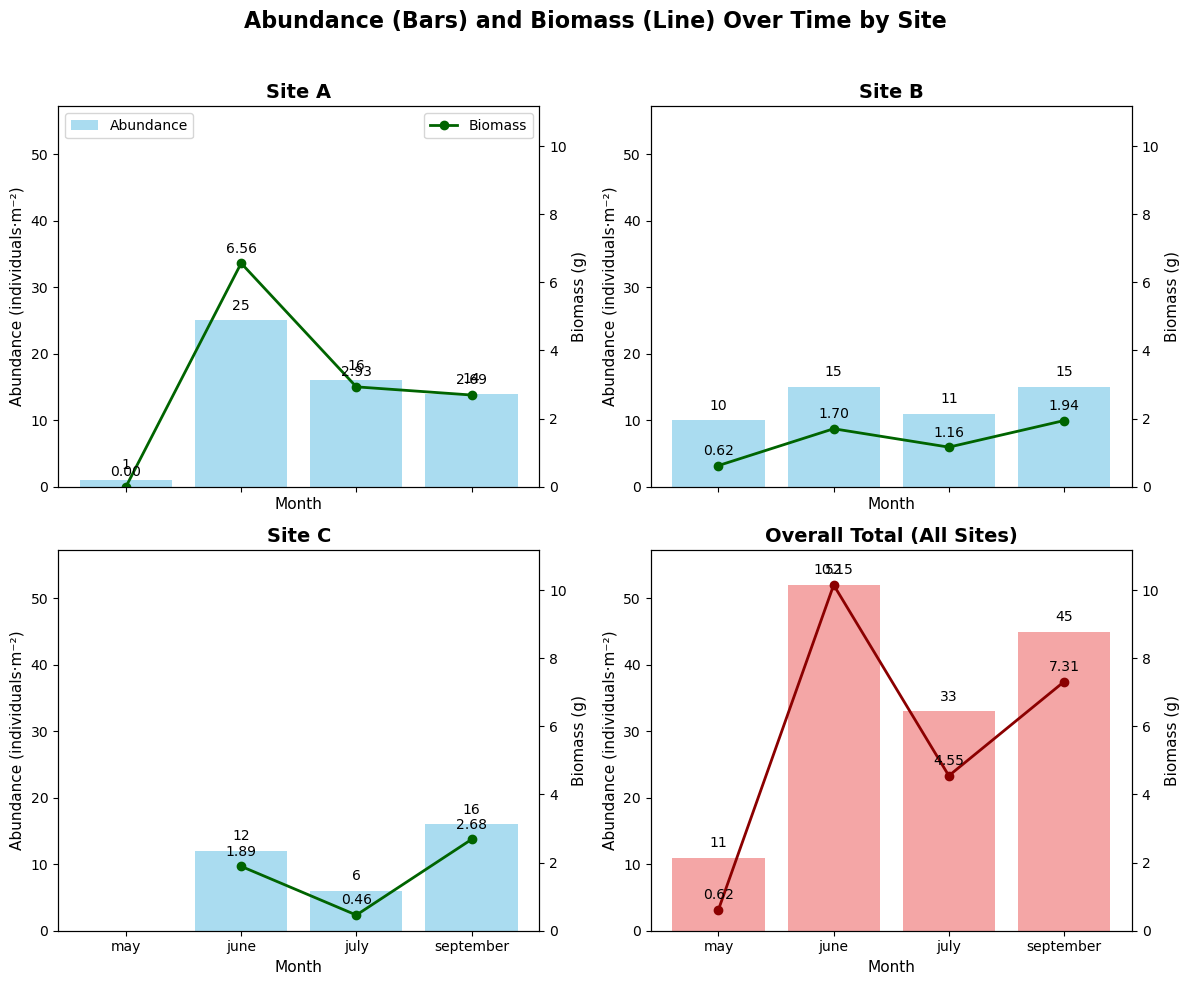

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure months are in correct order ---
month_order = ['may', 'june', 'july', 'september']

total_ab_site_series['month'] = pd.Categorical(
    total_ab_site_series['month'], categories=month_order, ordered=True
)
total_ab_site_series = total_ab_site_series.sort_values(['site', 'month'])

total_ab_series['month'] = pd.Categorical(
    total_ab_series['month'], categories=month_order, ordered=True
)
total_ab_series = total_ab_series.sort_values(['month'])

# --- Compute global axis limits for consistency ---
y1_min = 0
y1_max = max(total_ab_site_series['abundance'].max(),
             total_ab_series['abundance'].max()) * 1.1

y2_min = 0
y2_max = max(total_ab_site_series['biomass'].max(),
             total_ab_series['biomass'].max()) * 1.1

# --- Define site list and create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

# --- Loop through sites (A, B, C) ---
for i, site in enumerate(sites):
    site_data = total_ab_site_series[total_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance as bars
    bars = ax1.bar(site_data['month'], site_data['abundance'], 
                   color='skyblue', alpha=0.7, label='Abundance')
    
    # Plot biomass as line
    line = ax2.plot(site_data['month'], site_data['biomass'], 
                    color='darkgreen', marker='o', linewidth=2, label='Biomass')
    
    # Add abundance value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
                 f"{height:.0f}", ha='center', va='bottom', fontsize=10, color='black')
    
    # Add biomass value labels on line points
    for x, y in zip(site_data['month'], site_data['biomass']):
        ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='black')
    
    # Formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=14, weight='bold')
    ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=11, color='black')
    ax2.set_ylabel('Biomass (g)', fontsize=11, color='black')
    ax1.set_xlabel('Month', fontsize=11)
    
    # Show legend clearly
    if i == 0:
        ax1.legend(loc='upper left')
        ax2.legend(loc='upper right')
    
    # Remove grid lines
    ax1.grid(False)
    ax2.grid(False)

# --- Fourth subplot (Overall Total) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(total_ab_series['month'], total_ab_series['abundance'],
               color='lightcoral', alpha=0.7, label='Abundance')
line = ax2.plot(total_ab_series['month'], total_ab_series['biomass'],
                color='darkred', marker='o', linewidth=2, label='Biomass')

# Add abundance and biomass labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
             f"{height:.0f}", ha='center', va='bottom', fontsize=10, color='black')

for x, y in zip(total_ab_series['month'], total_ab_series['biomass']):
    ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='black')

ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title('Overall Total (All Sites)', fontsize=14, weight='bold')
ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=11, color='black')
ax2.set_ylabel('Biomass (g)', fontsize=11, color='black')
ax1.set_xlabel('Month', fontsize=11)

ax1.grid(False)
ax2.grid(False)

# --- Global formatting ---
fig.suptitle('Abundance (Bars) and Biomass (Line) Over Time by Site', fontsize=16, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(plot_path / "time_series_scaled_labels_full.png", dpi=300)
plt.show()


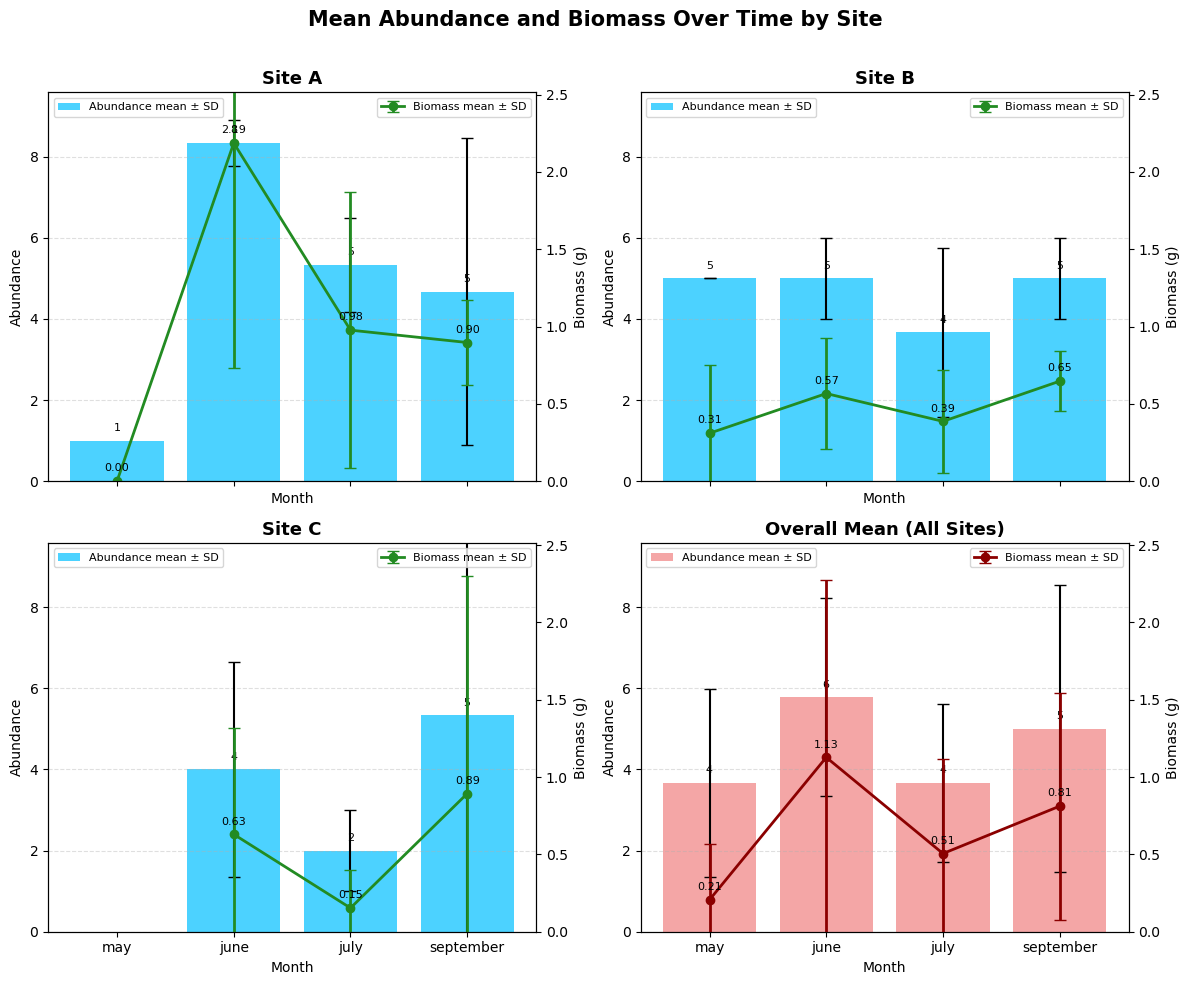

In [12]:
# --- Ensure month order ---
month_order = ['may', 'june', 'july', 'september']

mean_ab_series['month'] = pd.Categorical(mean_ab_series['month'], categories=month_order, ordered=True)
mean_ab_site_series['month'] = pd.Categorical(mean_ab_site_series['month'], categories=month_order, ordered=True)

mean_ab_series = mean_ab_series.sort_values(['month'])
mean_ab_site_series = mean_ab_site_series.sort_values(['site', 'month'])

# --- Compute global axis limits ---
y1_min = 0
y1_max = max(mean_ab_site_series['abundance_mean'].max(),
             mean_ab_series['abundance_mean'].max()) * 1.15

y2_min = 0
y2_max = max(mean_ab_site_series['biomass_mean'].max(),
             mean_ab_series['biomass_mean'].max()) * 1.15

# --- Create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

# --- Loop through sites ---
for i, site in enumerate(sites):
    site_data = mean_ab_site_series[mean_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance with SD
    bars = ax1.bar(site_data['month'], site_data['abundance_mean'],
                   yerr=site_data['abundance_std'], capsize=4,
                   color='deepskyblue', alpha=0.7, label='Abundance mean ± SD')
    
    # Plot biomass with SD
    ax2.errorbar(site_data['month'], site_data['biomass_mean'],
                 yerr=site_data['biomass_std'], color='forestgreen',
                 marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD')
    
    # Add bar labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
                 f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black')
    
    # Add biomass labels
    for x, y in zip(site_data['month'], site_data['biomass_mean']):
        ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='black')
    
    # Axis formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=13, weight='bold', color='black')
    ax1.set_ylabel('Abundance', fontsize=10, color='black')
    ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
    ax1.set_xlabel('Month', fontsize=10, color='black')
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add legend for SD/key
    ax1.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

# --- Fourth subplot: Overall Mean (All Sites) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(mean_ab_series['month'], mean_ab_series['abundance_mean'],
               yerr=mean_ab_series['abundance_std'], capsize=4,
               color='lightcoral', alpha=0.7, label='Abundance mean ± SD')

ax2.errorbar(mean_ab_series['month'], mean_ab_series['biomass_mean'],
             yerr=mean_ab_series['biomass_std'], color='darkred',
             marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD')

# Add labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
             f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black')

for x, y in zip(mean_ab_series['month'], mean_ab_series['biomass_mean']):
    ax2.text(x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='black')

# Axis formatting
ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title("Overall Mean (All Sites)", fontsize=13, weight='bold', color='black')
ax1.set_ylabel('Abundance', fontsize=10, color='black')
ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
ax1.set_xlabel('Month', fontsize=10, color='black')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax1.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# --- Global formatting ---
fig.suptitle("Mean Abundance and Biomass Over Time by Site", fontsize=15, weight='bold', color='black')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "mean_abundance_biomass_sites_sd.png", dpi=300)
plt.show()


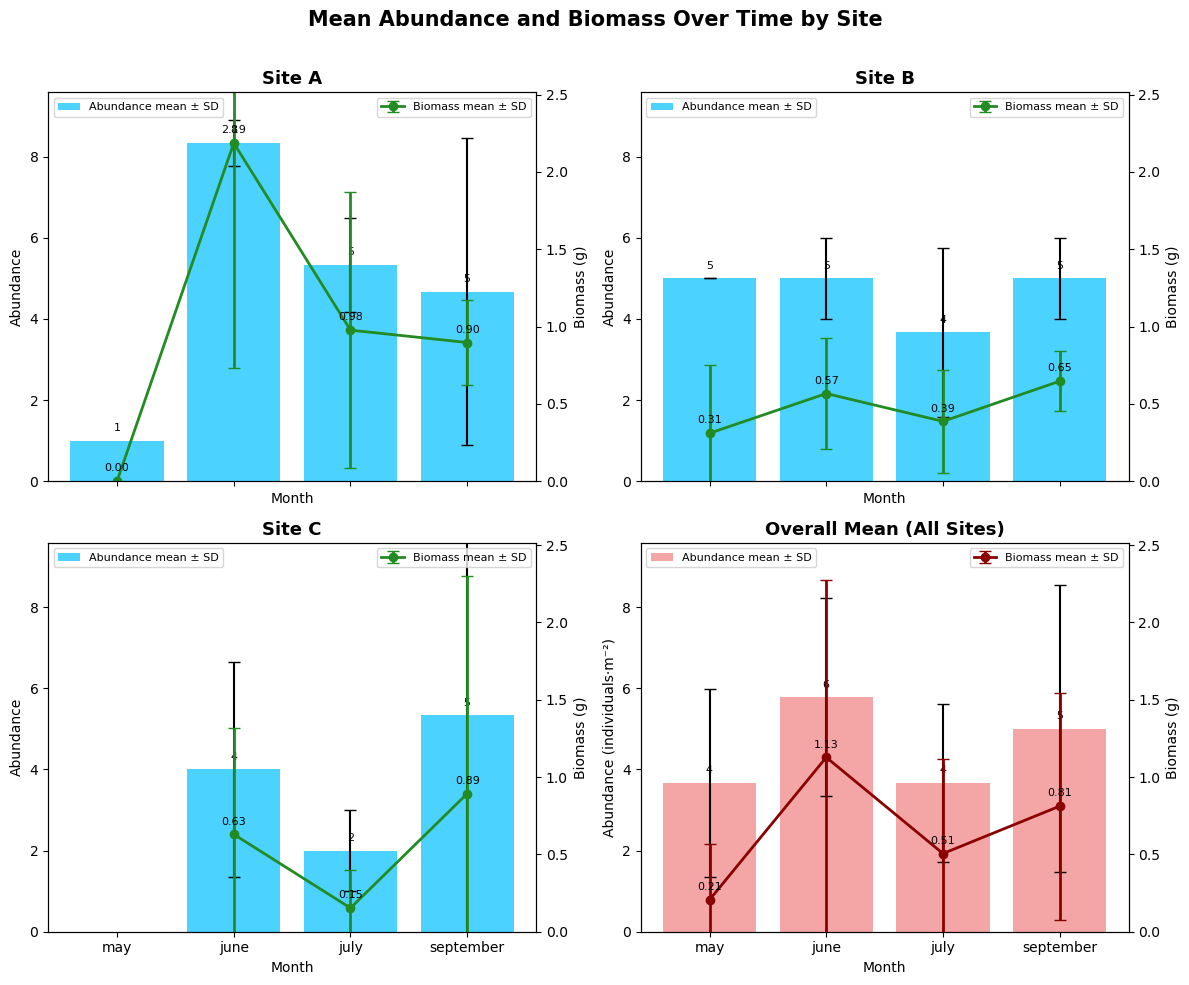

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Ensure month order ---
month_order = ['may', 'june', 'july', 'september']

mean_ab_series['month'] = pd.Categorical(
    mean_ab_series['month'], categories=month_order, ordered=True
)
mean_ab_site_series['month'] = pd.Categorical(
    mean_ab_site_series['month'], categories=month_order, ordered=True
)

mean_ab_series = mean_ab_series.sort_values(['month'])
mean_ab_site_series = mean_ab_site_series.sort_values(['site', 'month'])

# --- Compute global axis limits ---
y1_min = 0
y1_max = max(
    mean_ab_site_series['abundance_mean'].max(),
    mean_ab_series['abundance_mean'].max()
) * 1.15

y2_min = 0
y2_max = max(
    mean_ab_site_series['biomass_mean'].max(),
    mean_ab_series['biomass_mean'].max()
) * 1.15

# --- Create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

# --- Loop through sites ---
for i, site in enumerate(sites):
    site_data = mean_ab_site_series[mean_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance with SD
    bars = ax1.bar(
        site_data['month'], site_data['abundance_mean'],
        yerr=site_data['abundance_std'], capsize=4,
        color='deepskyblue', alpha=0.7, label='Abundance mean ± SD'
    )
    
    # Plot biomass with SD
    ax2.errorbar(
        site_data['month'], site_data['biomass_mean'],
        yerr=site_data['biomass_std'], color='forestgreen',
        marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD'
    )
    
    # Add bar labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
            f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black'
        )
    
    # Add biomass labels
    for x, y in zip(site_data['month'], site_data['biomass_mean']):
        ax2.text(
            x, y + y2_max*0.02, f"{y:.2f}",
            ha='center', va='bottom', fontsize=8, color='black'
        )
    
    # Axis formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=13, weight='bold', color='black')
    ax1.set_ylabel('Abundance', fontsize=10, color='black')
    ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
    ax1.set_xlabel('Month', fontsize=10, color='black')
    
    # Add legends
    ax1.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

# --- Fourth subplot: Overall Mean (All Sites) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(
    mean_ab_series['month'], mean_ab_series['abundance_mean'],
    yerr=mean_ab_series['abundance_std'], capsize=4,
    color='lightcoral', alpha=0.7, label='Abundance mean ± SD'
)

ax2.errorbar(
    mean_ab_series['month'], mean_ab_series['biomass_mean'],
    yerr=mean_ab_series['biomass_std'], color='darkred',
    marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD'
)

# Add labels
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
        f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black'
    )

for x, y in zip(mean_ab_series['month'], mean_ab_series['biomass_mean']):
    ax2.text(
        x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='black'
    )

# Axis formatting
ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title("Overall Mean (All Sites)", fontsize=13, weight='bold', color='black')
ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=10, color='black')
ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
ax1.set_xlabel('Month', fontsize=10, color='black')

ax1.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# --- Global formatting ---
fig.suptitle(
    "Mean Abundance and Biomass Over Time by Site",
    fontsize=15, weight='bold', color='black'
)
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "mean_abundance_biomass_sites_sd_nogrid.png", dpi=300)
plt.show()


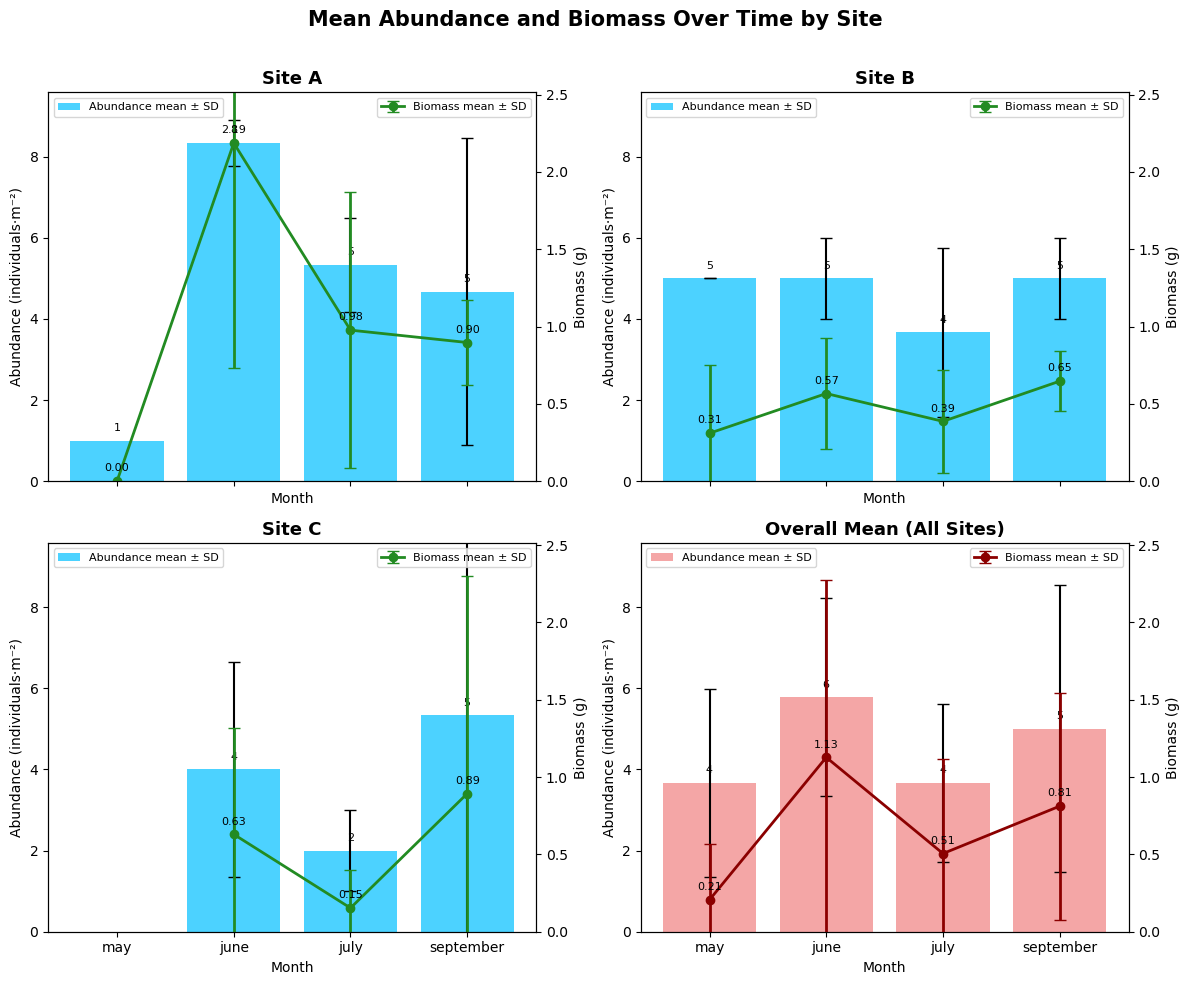

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Ensure month order ---
month_order = ['may', 'june', 'july', 'september']

mean_ab_series['month'] = pd.Categorical(
    mean_ab_series['month'], categories=month_order, ordered=True
)
mean_ab_site_series['month'] = pd.Categorical(
    mean_ab_site_series['month'], categories=month_order, ordered=True
)

mean_ab_series = mean_ab_series.sort_values(['month'])
mean_ab_site_series = mean_ab_site_series.sort_values(['site', 'month'])

# --- Compute global axis limits ---
y1_min = 0
y1_max = max(
    mean_ab_site_series['abundance_mean'].max(),
    mean_ab_series['abundance_mean'].max()
) * 1.15

y2_min = 0
y2_max = max(
    mean_ab_site_series['biomass_mean'].max(),
    mean_ab_series['biomass_mean'].max()
) * 1.15

# --- Create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

# --- Loop through sites ---
for i, site in enumerate(sites):
    site_data = mean_ab_site_series[mean_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance with SD
    bars = ax1.bar(
        site_data['month'], site_data['abundance_mean'],
        yerr=site_data['abundance_std'], capsize=4,
        color='deepskyblue', alpha=0.7, label='Abundance mean ± SD'
    )
    
    # Plot biomass with SD
    ax2.errorbar(
        site_data['month'], site_data['biomass_mean'],
        yerr=site_data['biomass_std'], color='forestgreen',
        marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD'
    )
    
    # Add bar labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
            f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black'
        )
    
    # Add biomass labels
    for x, y in zip(site_data['month'], site_data['biomass_mean']):
        ax2.text(
            x, y + y2_max*0.02, f"{y:.2f}",
            ha='center', va='bottom', fontsize=8, color='black'
        )
    
    # Axis formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=13, weight='bold', color='black')
    ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=10, color='black')
    ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
    ax1.set_xlabel('Month', fontsize=10, color='black')
    
    # Add legends
    ax1.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

# --- Fourth subplot: Overall Mean (All Sites) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(
    mean_ab_series['month'], mean_ab_series['abundance_mean'],
    yerr=mean_ab_series['abundance_std'], capsize=4,
    color='lightcoral', alpha=0.7, label='Abundance mean ± SD'
)

ax2.errorbar(
    mean_ab_series['month'], mean_ab_series['biomass_mean'],
    yerr=mean_ab_series['biomass_std'], color='darkred',
    marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD'
)

# Add labels
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
        f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black'
    )

for x, y in zip(mean_ab_series['month'], mean_ab_series['biomass_mean']):
    ax2.text(
        x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='black'
    )

# Axis formatting
ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title("Overall Mean (All Sites)", fontsize=13, weight='bold', color='black')
ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=10, color='black')
ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
ax1.set_xlabel('Month', fontsize=10, color='black')

ax1.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# --- Global formatting ---
fig.suptitle(
    "Mean Abundance and Biomass Over Time by Site",
    fontsize=15, weight='bold', color='black'
)
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "mean_abundance_biomass_sites_sd_units.png", dpi=300)
plt.show()


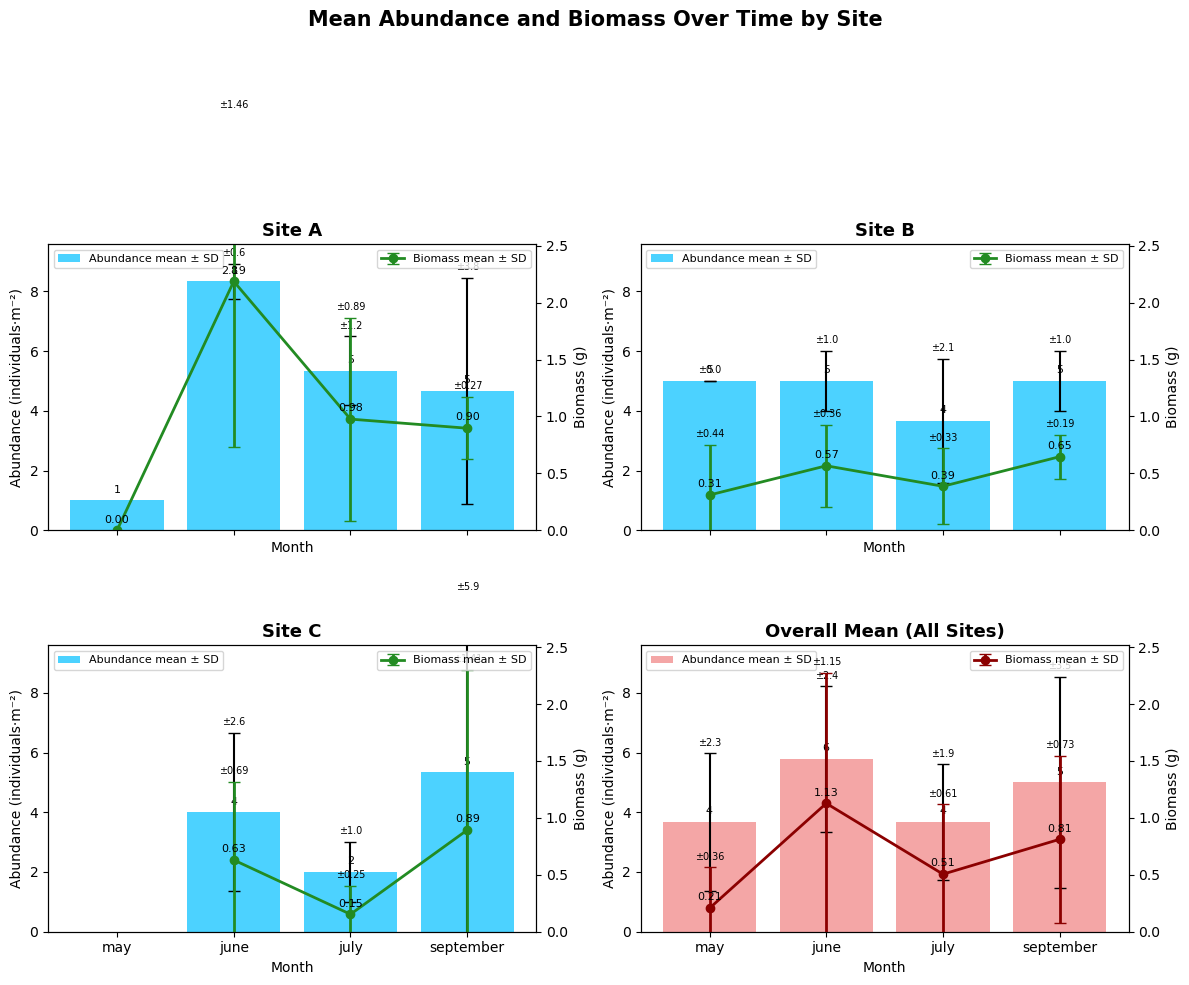

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Ensure month order ---
month_order = ['may', 'june', 'july', 'september']

mean_ab_series['month'] = pd.Categorical(
    mean_ab_series['month'], categories=month_order, ordered=True
)
mean_ab_site_series['month'] = pd.Categorical(
    mean_ab_site_series['month'], categories=month_order, ordered=True
)

mean_ab_series = mean_ab_series.sort_values(['month'])
mean_ab_site_series = mean_ab_site_series.sort_values(['site', 'month'])

# --- Compute global axis limits ---
y1_min = 0
y1_max = max(
    mean_ab_site_series['abundance_mean'].max(),
    mean_ab_series['abundance_mean'].max()
) * 1.15

y2_min = 0
y2_max = max(
    mean_ab_site_series['biomass_mean'].max(),
    mean_ab_series['biomass_mean'].max()
) * 1.15

# --- Create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

# --- Loop through sites ---
for i, site in enumerate(sites):
    site_data = mean_ab_site_series[mean_ab_site_series['site'] == site]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Plot abundance with SD
    bars = ax1.bar(
        site_data['month'], site_data['abundance_mean'],
        yerr=site_data['abundance_std'], capsize=4,
        color='deepskyblue', alpha=0.7, label='Abundance mean ± SD'
    )
    
    # Plot biomass with SD
    ax2.errorbar(
        site_data['month'], site_data['biomass_mean'],
        yerr=site_data['biomass_std'], color='forestgreen',
        marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD'
    )
    
    # Add abundance mean labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
            f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black'
        )
    
    # Add biomass mean labels
    for x, y in zip(site_data['month'], site_data['biomass_mean']):
        ax2.text(
            x, y + y2_max*0.02, f"{y:.2f}",
            ha='center', va='bottom', fontsize=8, color='black'
        )

    # --- Add SD text for abundance ---
    for x, mean, sd in zip(site_data['month'],
                           site_data['abundance_mean'],
                           site_data['abundance_std']):
        ax1.text(
            x, mean + sd + y1_max*0.02,
            f"±{sd:.1f}", ha='center', va='bottom', fontsize=7, color='black'
        )

    # --- Add SD text for biomass ---
    for x, mean, sd in zip(site_data['month'],
                           site_data['biomass_mean'],
                           site_data['biomass_std']):
        ax2.text(
            x, mean + sd + y2_max*0.02,
            f"±{sd:.2f}", ha='center', va='bottom', fontsize=7, color='black'
        )
    
    # Axis formatting
    ax1.set_ylim(y1_min, y1_max)
    ax2.set_ylim(y2_min, y2_max)
    ax1.set_title(f"Site {site}", fontsize=13, weight='bold', color='black')
    ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=10, color='black')
    ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
    ax1.set_xlabel('Month', fontsize=10, color='black')
    
    # Add legends
    ax1.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

# --- Fourth subplot: Overall Mean (All Sites) ---
ax1 = axes[3]
ax2 = ax1.twinx()

bars = ax1.bar(
    mean_ab_series['month'], mean_ab_series['abundance_mean'],
    yerr=mean_ab_series['abundance_std'], capsize=4,
    color='lightcoral', alpha=0.7, label='Abundance mean ± SD'
)

ax2.errorbar(
    mean_ab_series['month'], mean_ab_series['biomass_mean'],
    yerr=mean_ab_series['biomass_std'], color='darkred',
    marker='o', linewidth=2, capsize=4, label='Biomass mean ± SD'
)

# Add abundance mean labels
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2, height + y1_max*0.02,
        f"{height:.0f}", ha='center', va='bottom', fontsize=8, color='black'
    )

# Add biomass mean labels
for x, y in zip(mean_ab_series['month'], mean_ab_series['biomass_mean']):
    ax2.text(
        x, y + y2_max*0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='black'
    )

# --- Add SD text for abundance ---
for x, mean, sd in zip(mean_ab_series['month'],
                       mean_ab_series['abundance_mean'],
                       mean_ab_series['abundance_std']):
    ax1.text(
        x, mean + sd + y1_max*0.02,
        f"±{sd:.1f}", ha='center', va='bottom', fontsize=7, color='black'
    )

# --- Add SD text for biomass ---
for x, mean, sd in zip(mean_ab_series['month'],
                       mean_ab_series['biomass_mean'],
                       mean_ab_series['biomass_std']):
    ax2.text(
        x, mean + sd + y2_max*0.02,
        f"±{sd:.2f}", ha='center', va='bottom', fontsize=7, color='black'
    )

# Axis formatting
ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)
ax1.set_title("Overall Mean (All Sites)", fontsize=13, weight='bold', color='black')
ax1.set_ylabel('Abundance (individuals·m⁻²)', fontsize=10, color='black')
ax2.set_ylabel('Biomass (g)', fontsize=10, color='black')
ax1.set_xlabel('Month', fontsize=10, color='black')

ax1.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# --- Global formatting ---
fig.suptitle(
    "Mean Abundance and Biomass Over Time by Site",
    fontsize=15, weight='bold', color='black'
)
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "mean_abundance_biomass_sites_sd_units.png", dpi=300)
plt.show()
